# Required Packages:

- NumPy: For numerical computing
- Matplotlib: For visualizing solution to ODE and its applications
- Jupyter Lab: For running Jupyter notebooks.

All these packages are mentioned in `requirements.txt`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from solver import ivp

# What is an ODE?

Ordinary Differential Equation (ODEs), is a family of differential equations, which relates an unknown function of dependent variable with its derivatives. These equations are termed as ODE to distinguish then with Partial Differential Equations (PDEs).

## Examples of ODE:

$$
\frac{dy}{dx}+y=0,\qquad\frac{dy}{dx}+xy=0,\qquad\frac{dy}{dx}=\frac{2}{\sqrt{\pi}}e^{-x^2},\qquad\frac{d^2y}{dx^2}+\omega^2y=0,\space\text{etc. are some examples of ODEs}
$$
# Solving ODEs numerically:

We will first understand first-order ODEs using Euler's method, then move on to more advanced methods such as Midpoint method, Heun's method and Runge-Kutta method of order 4.

## Need for solving differential equations numerically:

Before understanding how to solve differential equations numerically, we need to understand why do we need to do this in the first place.

Simple equations like: $\frac{dy}{dx}=y$ or $\frac{d^2y}{dx^2}-3\frac{dy}{dx}+2y=0$ can be solved analytically, and their solutions are: $y=Ae^x$ and $A_{1}e^{2x}+A_{2}e^x$, where $A,A_1,A_2$ are arbitrary constants, which can be determined by giving appropriate conditions. The way these conditions are giving further create a new class of problems known as:
1. Initial Value Problems (IVP): This notebook focuses on techniques to solve IVP problems.
2. Boundary Value Problems (BVP): Another notebook will focus on techniques to solve BVP problems.

But anyway, these equations can be solved, but the equation $\frac{dy}{dx}=\frac{2}{\sqrt{\pi}}e^{-x^2}$ cannot be solved analytically because antiderivative of $e^{-x^2}$ cannot be expressed in terms of elementary functions. For this we could obviously use numerical integration techniques, but then the logistic equation with Allee's modification solved analytically looks very complex and it cannot be expressed as explicit function between $x$ and $y$. This creates a need for solving differential equations numerically.

## Solving first order ODEs using Euler's method:

Now that we know the problem in front of us, let us start with the solution, with the simplest method, that is the Euler's method.
$$\begin{align*}
&\text{A first order ODE is of form:}\\
&\frac{dy}{dx}=f(x,y)\\
&\text{Now that this is an IVP, the area of interest is from }a\text{ to }b\text{ with }y(a)=y_0\\
&\text{We know that we with derivative and a point, we can make local approximation on a function. We do so by using the formula:}\\
&y(x)=y(x_0)+f(x_0, y(x_0))(x-x_0)\\
&\text{To find approximation at }x=x_1\text{ we use the above equation.}\\
&\therefore y(x_1)=y(x_0)+f(x_0, y(x_0))(x_1-x_0)\\
&\therefore y(x_1)=y(x_0)+f(x_0, y(x_0))\Delta x\qquad \Delta x=x_1-x_0\\
&\text{We can apply the same concept here, first will divide whole area of interest into }N\text{ equally spaced interval with step size }h.\\
&\text{We will then approximate value of }y\text{ at the next step and keep on doing this till we reach the end of interval. As }h\rightarrow 0\text{, the approximation}\\
&\text{gets better.}\\
&h=\frac{b-a}{N}\\
&y(a+(i+1)h)=y(a+ih)+f(a+ih, y(a+ih))\Delta x\implies y(a+(i+1)h)=y(a+ih)+f(a+ih, y(a+ih))h\qquad\forall 0\leq i<N\\
&\text{A table of values:}\\
&\begin{array}
&x&&y\\
\hline
a&&y(a)\\
a+h&&y(a)+f(a, y(a))h\\
a+2h&&y(a+h)+f(a+h, y(a+h))h\\
\vdots&&\vdots\\
a+Nh=b&&y(a+(N-1)h)+f(a+(N-1)h, y(a+(N-1)h))h
\end{array}
\end{align*}$$

This is simply how Euler's method works!

Euler's method gives global error in order of $\mathcal{O}(h)$. This means the error decreases linearly as we decrease step size.

Other methods are somewhat variations of Euler's method.

## Solving first order ODEs using Midpoint method:

Euler's method gives global error at $\mathcal{O}(h)$, so we need some more better methods.

Midpoint method gives global error at $\mathcal{O}(h^2)$.

Here, instead of trusting the slope at the beginning, we find the slope at the center.

The reason we use center here is because, central difference gives more accurate approximation for differentiation, rather than forward or backward difference.

$$\begin{align*}
&\text{A first order ODE is of form:}\\
&\frac{dy}{dx}=f(x,y)\\
&\text{Now that this is an IVP, the area of interest is from }a\text{ to }b\text{ with }y(a)=y_0\\
&\text{We again divide our area of interest into }N\text{ equal parts with stepsize }h\\
&\text{We again start local approximation, but with a slight modification:}\\
&y(a+(i+1)h)=y(a+ih)+hf\left(a+ih+\frac{h}{2}, y\left(a+ih+\frac{h}{2}\right)\right)\qquad\forall 0\leq i<N\\
&y\left(a+ih+\frac{h}{2}\right)=y(a+ih)+\frac{h}{2}f(a+ih,  y(a+ih))\\
&\text{A table of values:}\\
&\begin{array}
&x&&y\\
\hline
a&&y(a)\\
a+h&&y(a)+f\left(a+\frac{h}{2}, y\left(a+\frac{h}{2}\right)\right)h\\
a+2h&&y(a+h)+f\left(a+h+\frac{h}{2}, y\left(a+h+\frac{h}{2}\right)\right)h\\
\vdots&&\vdots\\
a+Nh=b&&y(a+(N-1)h)+f\left(a+(N-1)h+\frac{h}{2}, y\left(a+(N-1)h+\frac{h}{2}\right)\right)h
\end{array}
\end{align*}$$

## Solving first order ODEs using Heun's method:

This method also gives global error in $\mathcal{O}(h^{2})$.

Here, we find 2 slopes:
1. At the beginning.
2. At the end.

Then we take their arithmetic mean and use that for finding next value of $y$. Quite simple method!

$$\begin{align*}
&\text{A first order ODE is of form:}\\
&\frac{dy}{dx}=f(x,y)\\
&\text{Now that this is an IVP, the area of interest is from }a\text{ to }b\text{ with }y(a)=y_0\\
&\text{We again divide our area of interest into }N\text{ equal parts with stepsize }h\\
&k_1=f(a+ih, y(a+ih))\\
&k_2=f(a+(i+1)h, y(a+(i+1)h))\qquad\text{Here,}\quad y(a+(i+1)h)=y(a+ih)+hf(a+ih, y(a+ih))\\
&y(a+(i+1)h)=y(a+ih)+h\left(\frac{k_1+k_2}{2}\right)\qquad\forall0\leq i< N\\
&\text{A table of values:}\\
&\begin{array}
&x&&k_1&&k_2&&y\\
\hline
a&&-&&-&&y(a)\\
a+h&&f(a, y(a))&&f(a+h, y(a+h))&&y(a)+h\left(\frac{k_1+k_2}{2}\right)\\
a+2h&&f(a+h, y(a+h))&&f(a+2h, y(a+2h))&&y(a+h)+h\left(\frac{k_1+k_2}{2}\right)\\
\vdots&&\vdots&&\vdots&&\vdots\\
a+Nh=b&&f(a+(N-1)h, y(a+(N-1)h))&&f(b, y(b))&&y(a+(N-1)h)+h\left(\frac{k_1+k_2}{2}\right)
\end{array}
\end{align*}$$

## Solving first order ODEs using RK4 method:

Runge-Kutta method of order 4 (RK4) is a very accurate, industry standard method, which has global error of order $\mathcal{O}(h^4)$

Just like how we needed to find $k_1, k_2$ in Heun's method, we have to find $k_1, k_2, k_3, k_4$ here. Note that this is not of order 4 because we are using 4 slopes, but because it's error is of order $\mathcal{O}(h^4)$.

The 4 slopes are:
1. At the beginning.
2. At the midpoint, using slope found in previous step
3. Using slope found in previous step to again find a better approximation at midpoint.
4. At the end, using slope found in previous step.

Then, we take their weighted mean and use that to find the next value of $y$. Again such a simple method!

$$\begin{align*}
&\text{A first order ODE is of form:}\\
&\frac{dy}{dx}=f(x,y)\\
&\text{Now that this is an IVP, the area of interest is from }a\text{ to }b\text{ with }y(a)=y_0\\
&\text{We again divide our area of interest into }N\text{ equal parts with stepsize }h\\
&k_1=f(a+ih, y(a+ih))\\
&k_2=f\left(a+ih+\frac{h}{2}, y\left(a+ih+\frac{h}{2}\right)\right)\qquad\text{Here,}\quad y\left(a+ih+\frac{h}{2}\right)=y(a+ih)+k_1\frac{h}{2}\\
&k_3=f\left(a+ih+\frac{h}{2}, y\left(a+ih+\frac{h}{2}\right)\right)\qquad\text{Here,}\quad y\left(a+ih+\frac{h}{2}\right)=y(a+ih)+k_2\frac{h}{2}\\
&k_4=f(a+(i+1)h, y(a+(i+1)h))\qquad\text{Here,}\quad y(a+(i+1)h)=y(a+ih)+k_3h\\
&\text{Now making a table with }x,k_1,k_2,k_3,k_4\text{ and }y\text{ would take more space and cause formatting errors, so I'll just make a table for }x\text{ and }y\\
&\begin{array}
&x&&y\\
\hline
a&&y(a)\\
a+h&&y(a)+h\left(\frac{k_1+2k_2+2k_3+k_4}{6}\right)\\
a+2h&&y(a+h)+h\left(\frac{k_1+2k_2+2k_3+k_4}{6}\right)\\
\vdots&&\vdots\\
a+Nh=b&&y(a+(N-1)h)+h\left(\frac{k_1+2k_2+2k_3+k_4}{6}\right)
\end{array}
\end{align*}$$

## An example:
Now let us take a look at how the 4 methods gives us the solution.

We will consider the simple ODE: $\frac{dy}{dx}=\cos(x)$, with $(0, 0)$ lying on the solution curve in the region $0\leq x<2\pi$ with stepsize $0.1$. Analytically the solution is $\sin(x)$

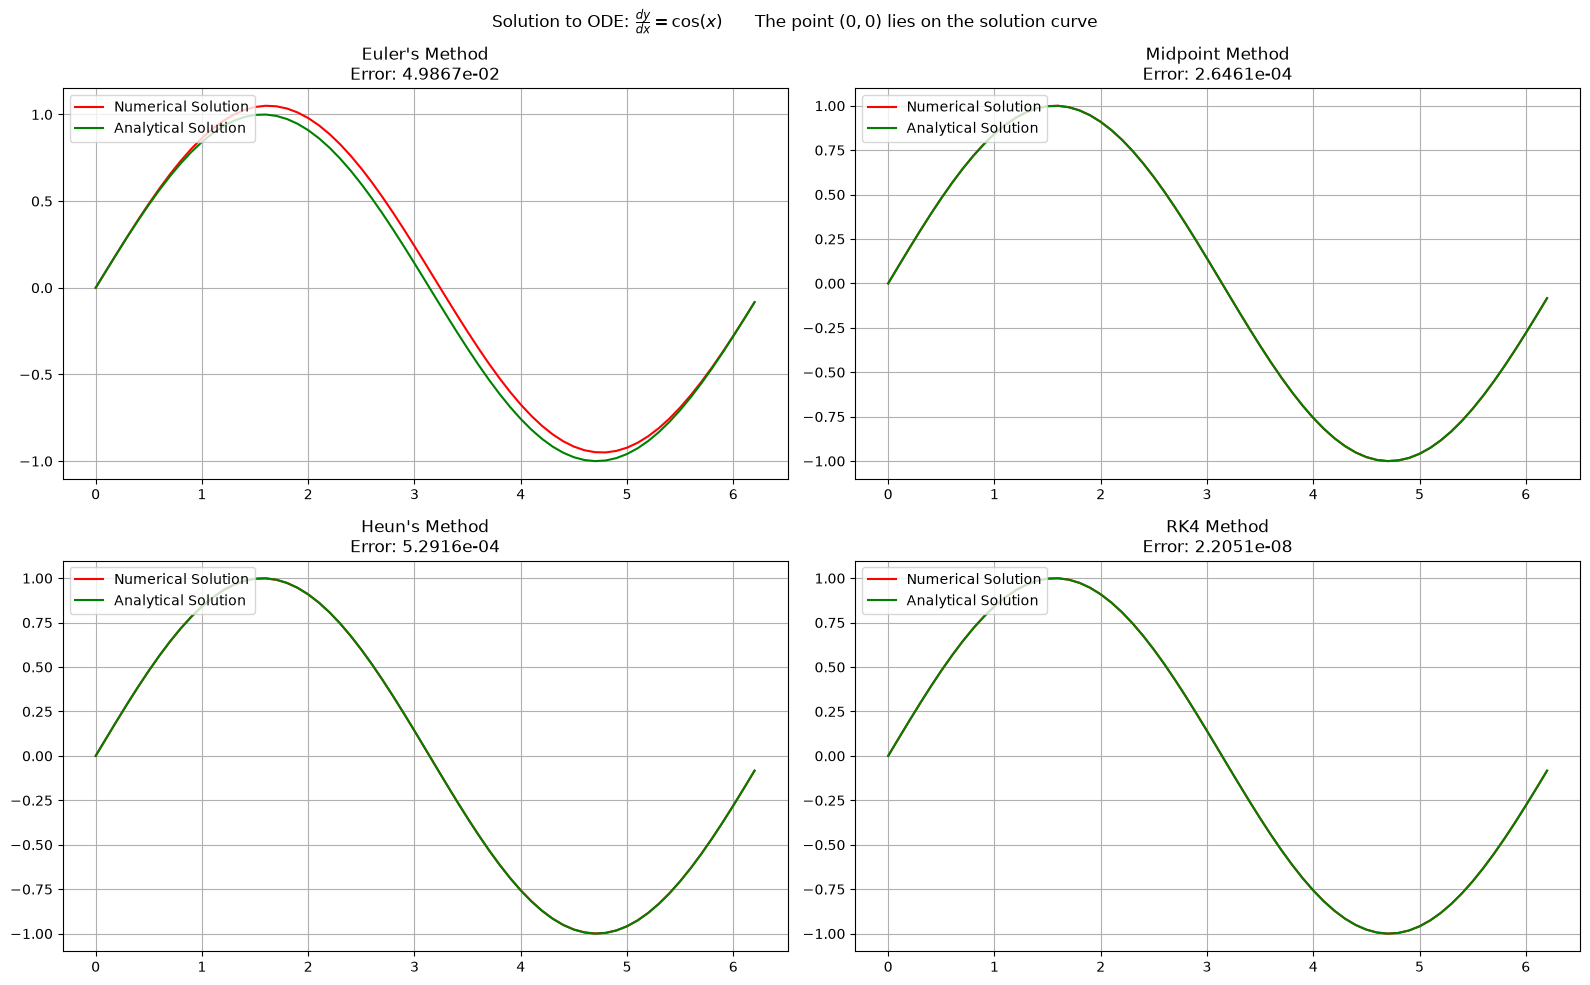

In [2]:
func = lambda x, y: np.cos(x)
sol = lambda x: np.sin(x)
a = 0
b = 2*np.pi
h = 0.1
data = {
    "func": func,
    "initial": 0
}
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

plt.suptitle(r"$\text{Solution to ODE: }\frac{dy}{dx}=\cos(x)\qquad\text{The point }(0, 0)\text{ lies on the solution curve}$")

x, y = ivp.euler_method(a, b, h, **data)
axes[0, 0].set_title(f"Euler's Method\nError: {np.mean(np.abs(y-sol(x))):.4e}")
axes[0, 0].plot(x, y, color="red", label="Numerical Solution")
axes[0, 0].plot(x, sol(x), color="green", label="Analytical Solution")
axes[0, 0].grid()
axes[0, 0].legend(loc="upper left")

x, y = ivp.midpoint_method(a, b, h, **data)
axes[0, 1].set_title(f"Midpoint Method\nError: {np.mean(np.abs(y-sol(x))):.4e}")
axes[0, 1].plot(x, y, color="red", label="Numerical Solution")
axes[0, 1].plot(x, sol(x), color="green", label="Analytical Solution")
axes[0, 1].grid()
axes[0, 1].legend(loc="upper left")

x, y = ivp.heun_method(a, b, h, **data)
axes[1, 0].set_title(f"Heun's Method\nError: {np.mean(np.abs(y-sol(x))):.4e}")
axes[1, 0].plot(x, y, color="red", label="Numerical Solution")
axes[1, 0].plot(x, sol(x), color="green", label="Analytical Solution")
axes[1, 0].grid()
axes[1, 0].legend(loc="upper left")

x, y = ivp.rk4(a, b, h, **data)
axes[1, 1].set_title(f"RK4 Method\nError: {np.mean(np.abs(y-sol(x))):.4e}")
axes[1, 1].plot(x, y, color="red", label="Numerical Solution")
axes[1, 1].plot(x, sol(x), color="green", label="Analytical Solution")
axes[1, 1].grid()
axes[1, 1].legend(loc="upper left")

plt.tight_layout()
plt.show()

## Solving second order ODEs:

A second order ODE is assumed to be of format: $\frac{d^2y}{dx^2}+P(x, y)\frac{dy}{dx}=Q(x, y)$

To solve a second order ODE, we have to find $\frac{dy}{dx}$ using $\frac{d^2y}{dx^2}$, then use it to find $y$.

The algorithm becomes:

1. Find $\frac{d^2y}{dx^2}$ at the point $a+ih$
2. Using $\frac{d^2y}{dx^2}$ obtained in previous step, find $\frac{dy}{dx}$.
3. Using $\frac{dy}{dx}$ obtained in previous step, find $y$.

Using this simple algorithm we can find solution to second order ODEs. We will need to seed in the initial value of $y$ and $\frac{dy}{dx}$.

## An example:

We will consider the simple second order ODE: $\frac{d^2y}{dx^2}-3\frac{dy}{dx}=x-2y$, in the region $(0, 2)$, with $y(0)=0\qquad y'(0)=0$ with stepsize $0.1$.

The analytical solution is: $y=\frac{e^{2x}}{4}-e^x+\frac{x}{2}+\frac{3}{4}$

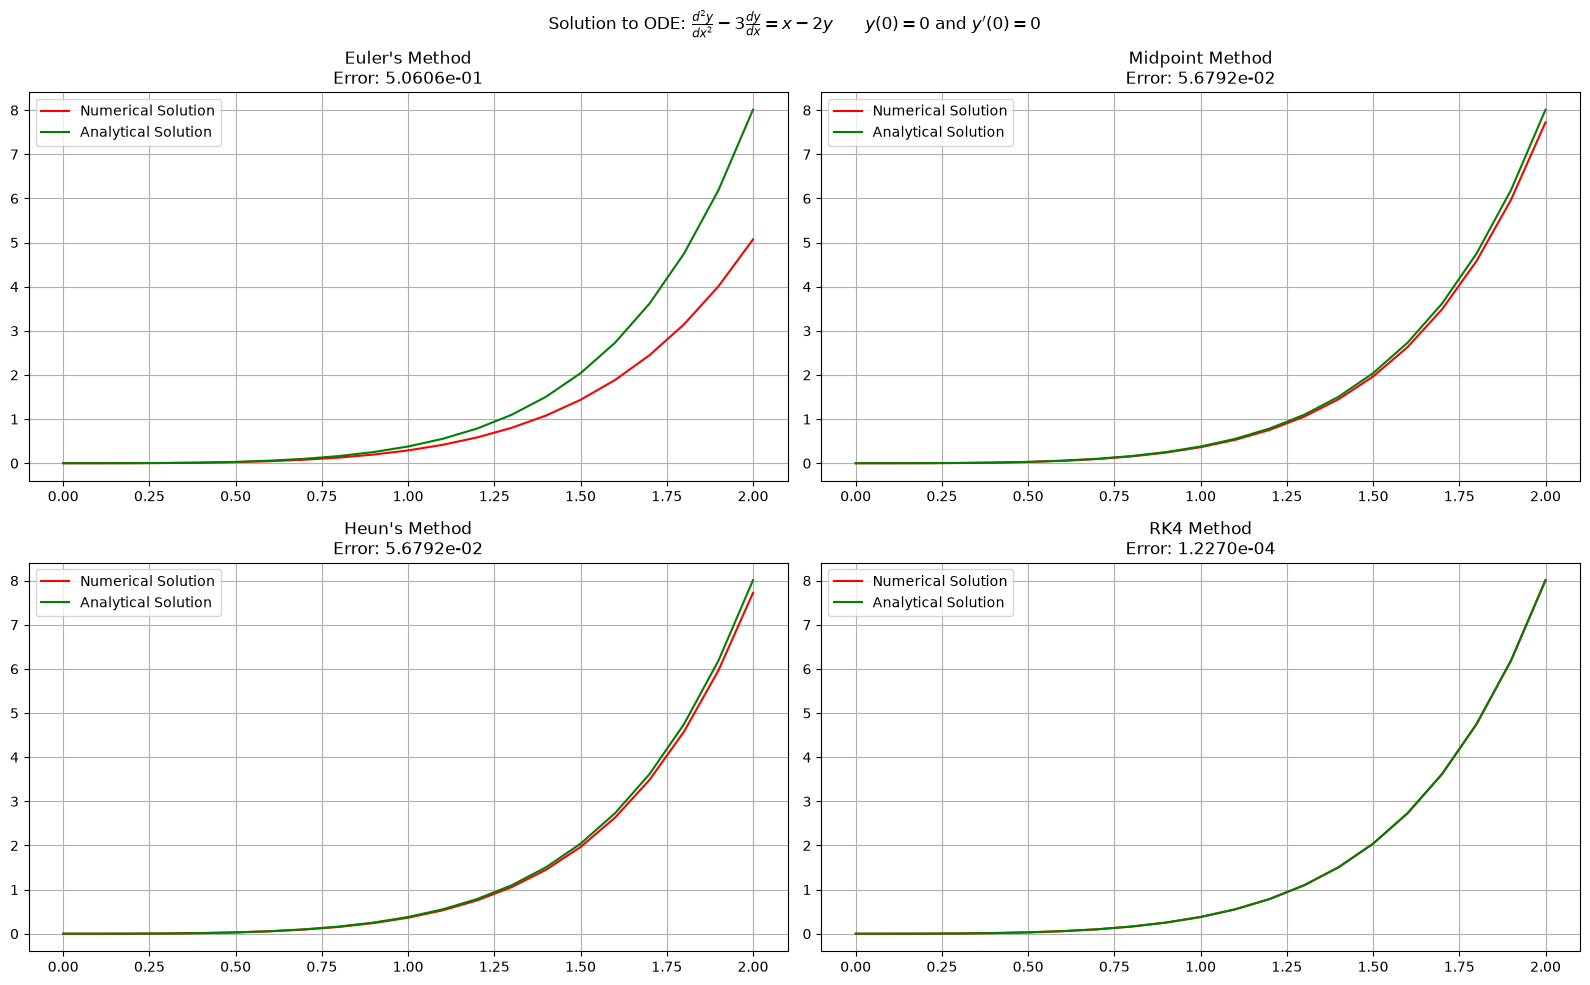

In [3]:
p = lambda x, y: -3
q = lambda x, y: x-2*y
sol = lambda x: 0.25*np.exp(2*x)-np.exp(x)+0.5*x+0.75
a = 0
b = 2
h = 0.1
data = {
    "p": p,
    "q": q,
    "initial": 0,
    "initial_slope": 0
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

plt.suptitle(r"$\text{Solution to ODE: }\frac{d^2y}{dx^2}-3\frac{dy}{dx}=x-2y\qquady(0)=0\text{ and }y'(0)=0$")

x, y = ivp.euler_method(a, b, h, **data)
axes[0, 0].set_title(f"Euler's Method\nError: {np.mean(np.abs(y-sol(x))):.4e}")
axes[0, 0].plot(x, y, color="red", label="Numerical Solution")
axes[0, 0].plot(x, sol(x), color="green", label="Analytical Solution")
axes[0, 0].grid()
axes[0, 0].legend(loc="upper left")

x, y = ivp.midpoint_method(a, b, h, **data)
axes[0, 1].set_title(f"Midpoint Method\nError: {np.mean(np.abs(y-sol(x))):.4e}")
axes[0, 1].plot(x, y, color="red", label="Numerical Solution")
axes[0, 1].plot(x, sol(x), color="green", label="Analytical Solution")
axes[0, 1].grid()
axes[0, 1].legend(loc="upper left")

x, y = ivp.heun_method(a, b, h, **data)
axes[1, 0].set_title(f"Heun's Method\nError: {np.mean(np.abs(y-sol(x))):.4e}")
axes[1, 0].plot(x, y, color="red", label="Numerical Solution")
axes[1, 0].plot(x, sol(x), color="green", label="Analytical Solution")
axes[1, 0].grid()
axes[1, 0].legend(loc="upper left")

x, y = ivp.rk4(a, b, h, **data)
axes[1, 1].set_title(f"RK4 Method\nError: {np.mean(np.abs(y-sol(x))):.4e}")
axes[1, 1].plot(x, y, color="red", label="Numerical Solution")
axes[1, 1].plot(x, sol(x), color="green", label="Analytical Solution")
axes[1, 1].grid()
axes[1, 1].legend(loc="upper left")

plt.tight_layout()
plt.show()